In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd ..\..

[Errno 2] No such file or directory: '....'
/content


In [2]:
!pip install matplotlib_scalebar

In [3]:
import sys, os
save_dir = '/content/drive/MyDrive/Colab Notebooks/MR MCD Pipeline/results/Recon_Moire/'  # Save images Path 220426
os.makedirs(save_dir, exist_ok=True)

PROJECT_ROOT = "/content/drive/MyDrive/Colab Notebooks/MR MCD Pipeline/2D"

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
    print("Added to sys.path:", PROJECT_ROOT)

print("Project root content:", os.listdir(PROJECT_ROOT))


Added to sys.path: /content/drive/MyDrive/Colab Notebooks/MR MCD Pipeline/2D
Project root content: ['Notebooks', 'data', 'Magnetisation']


In [4]:
import numpy as np
# 兼容补丁 / Compatibility patch
if not hasattr(np, "int"):
  np.int = int

In [5]:
import sys
import numpy as np
import json
import torch

from Magnetisation.Propagator import Propagator
from Magnetisation.Generator import generator_CNN
from Magnetisation.Train import Magnetisation_CNN_training
from Magnetisation.Evaluate import evaluate

import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
#from tqdm import tqdm
# unit_conversion = 1e-18 / 9.27e-24


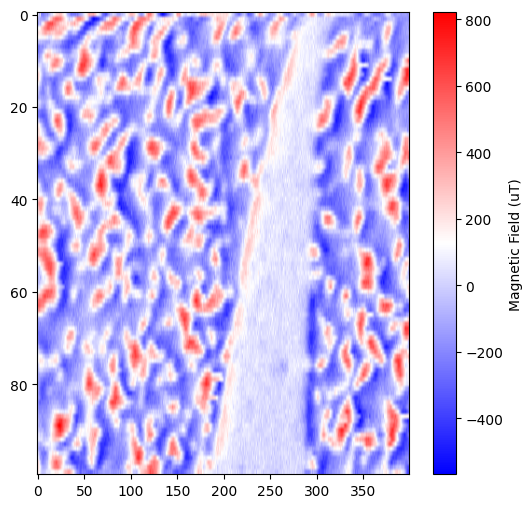

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Extract the data
#filename = 'data/Magnetisation out of plane/MoirePatten_Stuttgart.lvm'
filename = open('/content/drive/MyDrive/Colab Notebooks/MR MCD Pipeline/2D/data/Magnetisation out of plane/MoirePatten_Stuttgart.lvm') #current data path

lvm = np.loadtxt(filename).reshape(100,800)


Xdata = np.linspace(0,3000,400)
Ydata = np.linspace(0,3000,100)

MagneticField = 1e-6 *lvm[::,0:400] / (2.8e4)
fft_signal = np.fft.fft2(MagneticField)
fft_signal_clean = np.where(fft_signal.imag==0,0,fft_signal)
MagneticField = np.fft.ifft2(fft_signal_clean).real


fig = plt.figure()
# to change size of subplot's
# set height of each subplot as 8
fig.set_figheight(6)
# set width of each subplot as 8
fig.set_figwidth(6)
#PROP.MagneticFieldExtended = np.where(np.abs(PROP.MagneticFieldExtended) <(PROP.MagneticFieldExtended.mean()+PROP.MagneticFieldExtended.std()), 0, PROP.MagneticFieldExtended)

plt.imshow(1e6*MagneticField, cmap="bwr", aspect="auto")
plt.colorbar(label="Magnetic Field (uT)")
plt.savefig(save_dir + '1_input_magnetic_field.png', dpi=300, bbox_inches='tight')  # ← Save images
plt.show()
#plt.clim([-20, 20])




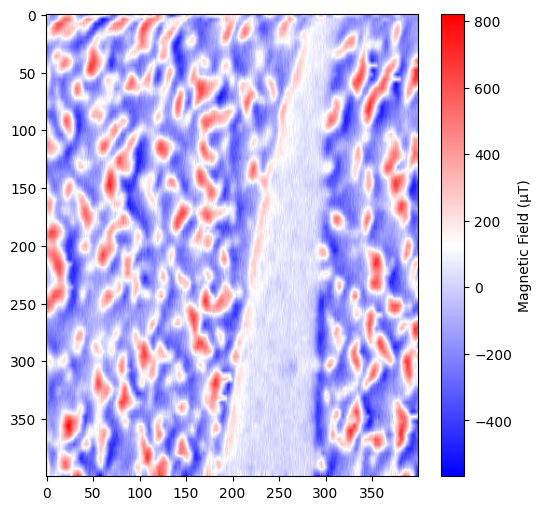

In [7]:
from scipy.interpolate import RegularGridInterpolator
import numpy as np
import matplotlib.pyplot as plt

# original grid
x = np.arange(0, 3000, 3000/400)
y = np.arange(0, 3000, 3000/100)

# new grid for interpolation
xnew = np.arange(0, 3000, 3000/400)
ynew = np.arange(0, 3000, 3000/400)

# prepare interpolator (allow out of bounds)
f = RegularGridInterpolator(
    (y, x),
    MagneticField,
    method='linear',
    bounds_error=False,
    fill_value=None  # extrapolate instead of error
)

# create mesh for evaluation
xx, yy = np.meshgrid(xnew, ynew)
points = np.column_stack([yy.ravel(), xx.ravel()])  # (N, 2)

MagnetInterp = f(points).reshape(len(ynew), len(xnew))

# plot
plt.figure(figsize=(6, 6))
plt.imshow(1e6 * MagnetInterp, cmap="bwr", aspect="auto")
plt.colorbar(label="Magnetic Field (µT)")
plt.savefig(save_dir + '2_interpolated_field.png', dpi=300, bbox_inches='tight')
plt.show()



# interp the data
# from scipy import interpolate

# x = np.arange(0, 3000, 3000/400)
# y = np.arange(0, 3000, 3000/100)

# xnew = np.arange(0, 3000, 3000/400)
# ynew = np.arange(0, 3000, 3000/400)

# xx, yy = np.meshgrid(x, y)
# f = interpolate.interp2d(x, y, MagneticField, kind='cubic')
# MagnetInterp = f(xnew, ynew)

# fig = plt.figure()
# # to change size of subplot's
# # set height of each subplot as 8
# fig.set_figheight(6)
# # set width of each subplot as 8
# fig.set_figwidth(6)
# #PROP.MagneticFieldExtended = np.where(np.abs(PROP.MagneticFieldExtended) <(PROP.MagneticFieldExtended.mean()+PROP.MagneticFieldExtended.std()), 0, PROP.MagneticFieldExtended)

# plt.imshow(1e6* MagnetInterp, cmap="bwr", aspect="auto")
# plt.colorbar(label="Magnetic Field (uT)")


In [8]:
import numpy as np
# 兼容补丁 / Compatibility patch
if not hasattr(np, "int"):
  np.int = int

[[-6.49958950e-05  7.30685488e-05 -6.49958950e-05 ... -1.57540432e-04
  -1.39360678e-04 -1.01806059e-04]
 [-5.81389699e-05  3.67854719e-05 -6.35644804e-05 ... -1.56474589e-04
  -1.48367993e-04 -1.07570161e-04]
 [-5.12820447e-05  5.02395009e-07 -6.21330659e-05 ... -1.55408746e-04
  -1.57375307e-04 -1.13334262e-04]
 ...
 [ 2.70625528e-04  1.78086121e-04  1.38912140e-04 ... -3.69214336e-04
  -3.92510810e-04 -2.95562577e-04]
 [ 2.74476106e-04  1.72771734e-04  1.36239913e-04 ... -3.76589476e-04
  -4.01986930e-04 -2.95787627e-04]
 [ 2.78326684e-04  1.67457347e-04  1.33567687e-04 ... -3.83964617e-04
  -4.11463049e-04 -2.96012678e-04]]


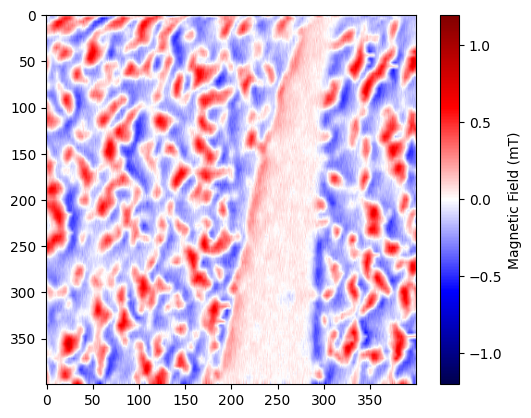

In [9]:
MagneticField = MagnetInterp

PropagationOptions = dict()
PropagationOptions['PixelSize'] = (3000e-9)/400
PropagationOptions['PixelSizeY'] = (3000e-9)/400
PropagationOptions['ImageShape'] = 512
PropagationOptions['NV'] = dict()
PropagationOptions['NV']['FindTheta']= False
PropagationOptions['NV']['Theta'] = 53
PropagationOptions['NV']['FindPhi']= False
PropagationOptions['NV']['Phi'] = 282
PropagationOptions['NV']['Height'] = 50e-9
PropagationOptions['Magnetisation'] = dict()
PropagationOptions['Magnetisation']['FindTheta']=False
PropagationOptions['Magnetisation']['Theta'] = 0
PropagationOptions['Magnetisation']['FindPhi']= False
PropagationOptions['Magnetisation']['Phi'] = 0
PropagationOptions['FFT'] = dict()
PropagationOptions["FFT"]["PaddingFactor"]= 2
PropagationOptions["FFT"]["performPadding"]= False
PropagationOptions["FFT"]["PaddingMode"] = 'constant'
PropagationOptions['FFT']['Extended'] = False
PropagationOptions['FFT']['Extention'] = 100
PropagationOptions['FFT']['Filter'] = dict()
PropagationOptions['FFT']['Filter']['useHanning'] = False
PropagationOptions['FFT']['Filter']['useHighCutoff'] = False
PropagationOptions['FFT']['Filter']['useLowCutoff'] = False
PropagationOptions['FFT']['Filter']['LambdaHighCutoff'] = 100e-9
PropagationOptions['FFT']['Filter']['LambdaLowCutoff'] = 7e-06

PROP = Propagator(PropagationOptions, MagneticField,PropagationOptions['ImageShape'])
# Extend the data set to the requested square dimensions
# Returns to self.MagneticFieldExtended


plt.imshow(1e3*MagneticField, cmap="seismic",vmin = -1.2, vmax = 1.2)
plt.colorbar(label="Magnetic Field (mT)") #plt.clim([-20, 20])
plt.savefig(save_dir + '3_magnetic_field_mT.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
Generator = generator_CNN(Size=1, ImageSize=PropagationOptions['ImageShape']).to(device)

In [12]:
ML_options = dict()
ML_options['mlp']=False
ML_options['LossFunction'] = 'L1'
ML_options['Epochs'] = 50
ML_options['Magnetization'] = None
ML_options['PositiveMagnetisationOnly'] = False
ML_options['PrintLossValue'] = False
ML_options['IntegerOnly'] = False

  0%|          | 0/50 [00:00<?, ?it/s]/content/drive/MyDrive/Colab Notebooks/MR MCD Pipeline/2D/Magnetisation/Propagator.py:374: RuntimeWarning: invalid value encountered in divide
  [-(kx ** 2) / k, -(kx * ky) / k, -1j * kx],
/content/drive/MyDrive/Colab Notebooks/MR MCD Pipeline/2D/Magnetisation/Propagator.py:375: RuntimeWarning: invalid value encountered in divide
  [-kx * ky / k, -(ky ** 2 / k), -1j * ky],
100%|██████████| 50/50 [00:32<00:00,  1.52it/s]
/content/drive/MyDrive/Colab Notebooks/MR MCD Pipeline/2D/Magnetisation/Train.py:249: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/content/drive/MyDrive/Colab Notebooks/MR MCD Pipeline/2D/Magnetisation/Train.py:256: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(

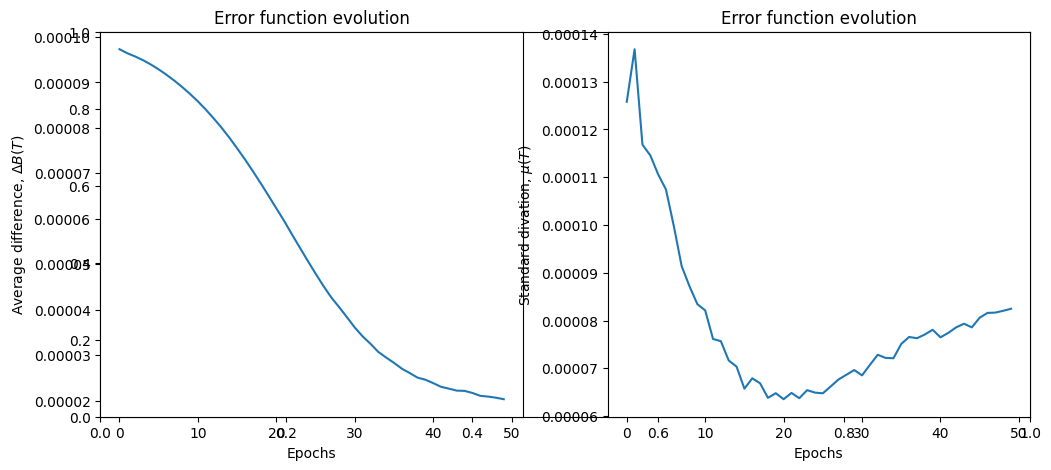

In [13]:
# Train the network
CNN_training = Magnetisation_CNN_training(device, Generator, PROP, ML_options)
bnv_cnn = CNN_training.train_cnn(**ML_options)
plt.savefig(save_dir + '4_training_loss.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
means,stds,pred,ci_upper,ci_lower, ic_acc,ic_acc2,loss = CNN_training.evaluateCNN()

Final MagnetisationMap shape: (512, 512)
Final ReconstructedBnv shape: (512, 512)


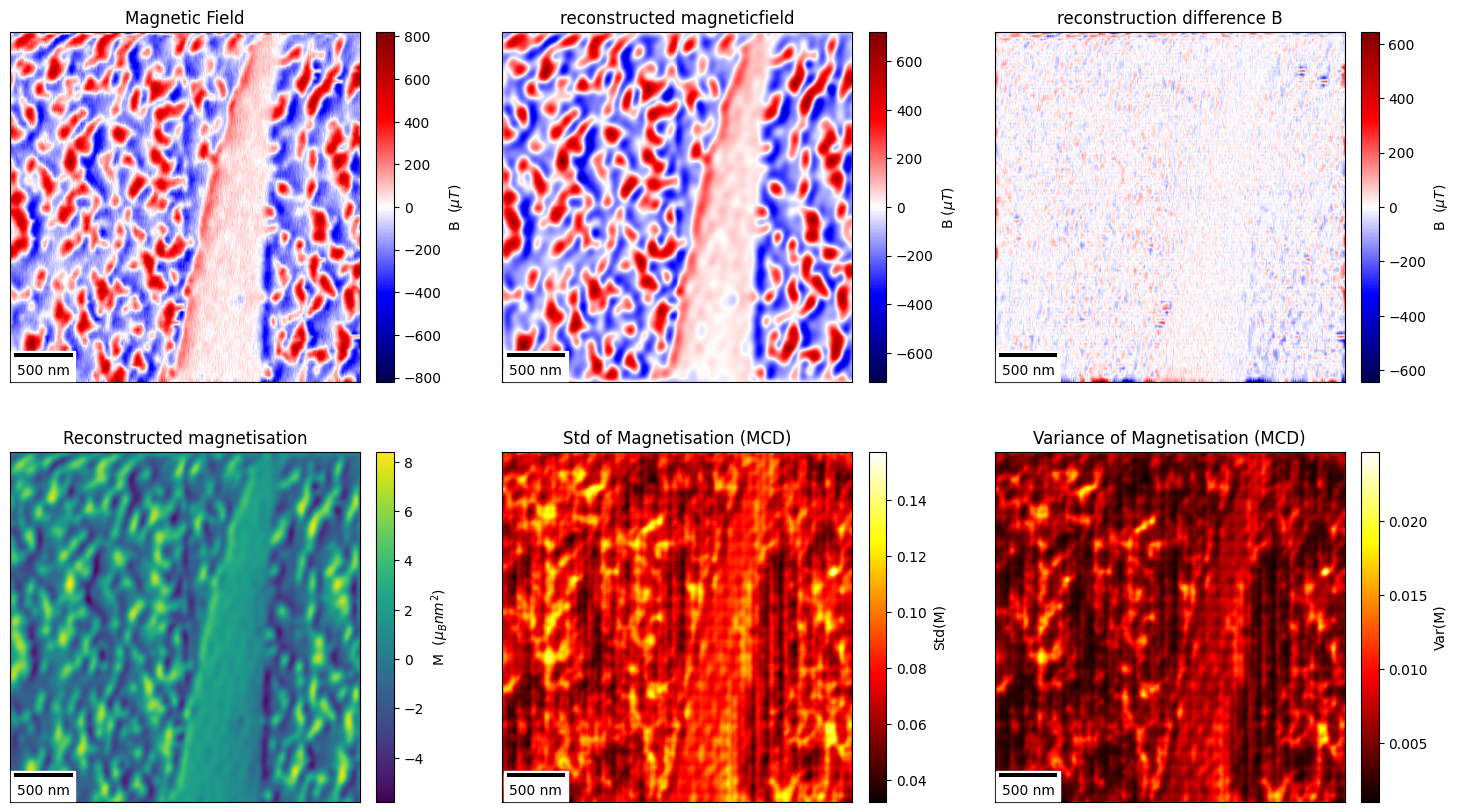

In [15]:
Results = CNN_training.extract_results(plotResults = True)
plt.savefig(save_dir + '5_reconstruction_results.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
OriginalMagneticField = np.flipud(Results['Original B'])[2:-2,2:-2]
Bnv_NN = np.flipud(Results['Reconstructed B'])[2:-2,2:-2]
Magnetisation_NN = np.flipud(Results['Magnetisation'])[2:-2,2:-2]

<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_4909/2998151155.py:14: SyntaxWarning: invalid escape sequence '\m'
  plt.colorbar(fraction=0.046, pad=0.04,label="B  ($\mu T)$")
/tmp/ipykernel_4909/2998151155.py:24: SyntaxWarning: invalid escape sequence '\m'
  plt.colorbar(fraction=0.046, pad=0.04,label="M  ($\mu_B nm^2$)")


np.float32(8.395112)

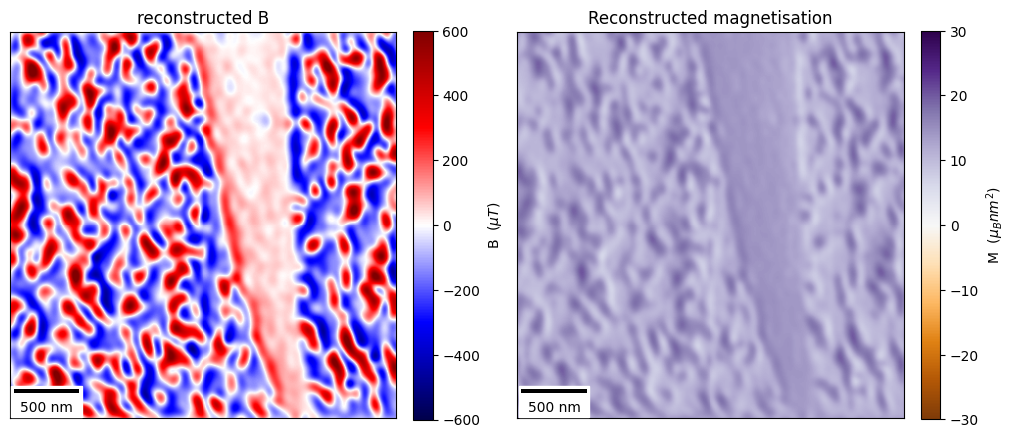

In [17]:
fig = plt.figure()
# to change size of subplot's
# set height of each subplot as 8
fig.set_figheight(6)
# set width of each subplot as 8
fig.set_figwidth(12)

ax3 = plt.subplot(1,2,1)
plt.imshow(1e6*Bnv_NN,cmap='seismic')
scalebar = ScaleBar(PropagationOptions['PixelSize'], location='lower left')
ax3.add_artist(scalebar)
plt.xticks([])
plt.yticks([])
plt.colorbar(fraction=0.046, pad=0.04,label="B  ($\mu T)$")
plt.clim([-600,600])
plt.title('reconstructed B')

ax4 = plt.subplot(1,2,2)
plt.imshow(Magnetisation_NN + 12,cmap='PuOr')
scalebar = ScaleBar(PropagationOptions['PixelSize'], location='lower left')
ax4.add_artist(scalebar)
plt.xticks([])
plt.yticks([])
plt.colorbar(fraction=0.046, pad=0.04,label="M  ($\mu_B nm^2$)")
plt.clim([-30,30])
plt.title('Reconstructed magnetisation')

display(np.max(Magnetisation_NN))
plt.savefig(save_dir + '6_reconstructed_B_and_magnetisation.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from Magnetisation.utils import SaveDictToJson
# SaveDictToJson("Results/ML_Reconstruction_Moire_Pattern", Results)